# HomeMatch — Capstone Project  

Prepared by: Group 1  
Date: September 17, 2025  
Project Type: Capstone — Intelligent Rental Matching Web App  


## Introduction  


HomeMatch is a smart, interactive platform designed to connect renters with property owners in real-time.  
This capstone notebook demonstrates the *data-driven logic* that powers the HomeMatch web app: predictive price modeling, geospatial filtering, and an intelligent recommendation engine.  

Unlike traditional rental platforms, HomeMatch ensures that users always receive *relevant suggestions*, even when no exact matches are found. This is achieved by combining:  
- *Predictive modeling (XGBoost)* to estimate property prices.  
- *Geo-search (Haversine distance)* to prioritize nearest available homes.  
- *Content-based recommendation engine* to suggest similar units.  
- *Dashboard metrics & visualizations* for property owners and admins.  

##  Problem Statement 


- Renters waste time browsing outdated or irrelevant listings.  
- Property owners struggle to reach the right tenants quickly.  
- Existing platforms lack predictive intelligence, geospatial context, and fallback recommendations.  

Opportunity: Deliver a fast, intelligent matching system that integrates prediction, geospatial search, and recommendations to reduce search time and increase occupancy.  


- Build and tune a predictive *machine learning model* for rental prices.  
- Implement *geospatial filtering* to recommend nearby listings.  
- Develop a *content-based recommendation engine* using property metadata.  
- Provide a *dashboard preview* with key rental metrics.  
- Integrate all logic into a single, executable notebook (backbone of the HomeMatch MVP).  

## Dataset Overview  

The dataset contains structured property listings with attributes such as:  
- *Location* (Latitude, Longitude)  
- *Bedrooms, Bathrooms*  
- *Price, Area*  
- *Amenities, Furnishing*  
- *Availability*  

## Notebook Structure  

1. *Data Loading & Initial Inspection*  
2. *Exploratory Data Analysis (EDA)*  
3. *Predictive Modeling (XGBoost with hyperparameter tuning)*  
4. *Geo-search: Nearest Homes using Haversine*  
5. *Content-based Recommendation Engine*  
6. *Dashboard Preview (metrics + visualizations)*  
7. *Export models & integration with Streamlit demo app*

In [1]:
# Imports & config
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import re
import psycopg2
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, HTML
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import joblib, json, os
import pickle




load_dotenv()
CSV_FALLBACK = '"/Users/chebet/Desktop/HomeMatch_Kenya_App/HomeMatch_Kenya_Housing.csv"'
DB_USER = os.getenv('POSTGRES_USER', 'homematch')
DB_PASS = os.getenv('POSTGRES_PASSWORD', 'homematch')
DB_HOST = os.getenv('POSTGRES_HOST', 'localhost')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'homematch_db')
print('CSV fallback:', CSV_FALLBACK)


CSV fallback: "/Users/chebet/Desktop/HomeMatch_Kenya_App/HomeMatch_Kenya_Housing.csv"


In [2]:


def test_postgres_connection():
    try:
        # 🔑 Adjust credentials as needed
        conn = psycopg2.connect(
            dbname="homematch_db",
            user="chebet",
            password="your_password",  # replace with your real password
            host="localhost",
            port="5432"
        )
        cur = conn.cursor()
        
        # Test query: check if table exists
        cur.execute("""
            SELECT table_name 
            FROM information_schema.tables 
            WHERE table_schema = 'public';
        """)
        tables = cur.fetchall()
        
        print("✅ Connected successfully.")
        print("Available tables in 'public' schema:")
        for t in tables:
            print("-", t[0])
        
        cur.close()
        conn.close()
    except Exception as e:
        print("❌ Database connection failed:", e)

# Run the test
test_postgres_connection()


✅ Connected successfully.
Available tables in 'public' schema:
- housing_listings


In [3]:


# Set your fallback path (absolute path is safest)
CSV_FALLBACK = "/Users/chebet/Desktop/HomeMatch_Kenya_App/HomeMatch_Kenya_Housing.csv"

def load_data():
    # 1. Try database
    try:
        conn = psycopg2.connect(
            dbname="homematch_db",
            user="chebet",
            password="your_password",  # replace with your real password
            host="localhost",
            port="5432"
        )
        print("Connected to database ✅")
        df = pd.read_sql("SELECT * FROM housing_listings", conn)
        conn.close()
        return df
    except Exception as e:
        print("⚠️ Database not available:", e)

    # 2. Try CSV fallback
    if os.path.exists(CSV_FALLBACK):
        print("Loading CSV fallback ✅")
        return pd.read_csv(CSV_FALLBACK)

    # 3. If neither works → raise
    raise FileNotFoundError(
        f"No dataset found.\n"
        f"Tried database 'homematch_db.housing_listings' "
        f"and CSV at {CSV_FALLBACK}"
    )

# --- Load and confirm ---
df = load_data()
print("Loaded dataset with shape:", df.shape)


Connected to database ✅
Loaded dataset with shape: (3000, 15)


/var/folders/ht/zbr8w6793p5bxcm924rzym5c0000gn/T/ipykernel_7679/2038720770.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM housing_listings", conn)


## EDA — quick checks
Inspect columns, head, missing values, and basic statistics.

In [4]:
pd.options.display.max_columns = 80
print(df.columns.tolist())
df.head()


['listing_id', 'city', 'location_name', 'latitude', 'longitude', 'property_type', 'price_ksh', 'bedrooms', 'bathrooms', 'area_size_sqm', 'availability_status', 'available_from', 'amenities', 'date_listed', 'image_url']


,listing_id,city,location_name,latitude,longitude,property_type,price_ksh,bedrooms,bathrooms,area_size_sqm,availability_status,available_from,amenities,date_listed,image_url
0,HM00001,Mombasa,Nyali,-4.023260,39.666938,Maisonette,60000,3,2,132,Vacant,2025-09-12,"Balcony, Parking, Pool, Gym, Furnished, Security",2025-07-23,https://example.com/images/HM00001.jpg
1,HM00002,Mombasa,Mtwapa,-4.072105,39.711487,Studio,33790,1,1,73,Vacant,2025-09-12,"Water, Balcony",2025-06-11,https://example.com/images/HM00002.jpg
2,HM00003,Nairobi,Lavington,-1.205134,36.787221,Apartment,66744,2,2,82,Vacant,2025-09-12,"Gym, Pool",2025-04-16,https://example.com/images/HM00003.jpg
3,HM00004,Eldoret,Langas,0.499456,35.282250,Townhouse,35000,2,2,96,Vacant,2025-09-12,"Parking, Electricity",2025-05-29,https://example.com/images/HM00004.jpg
4,HM00005,Eldoret,Kapsoya,0.593978,35.291814,Bungalow,21001,2,2,83,Vacant,2025-09-12,"Furnished, Water, Electricity, CCTV",2025-07-12,https://example.com/images/HM00005.jpg


In [5]:
print('Missing values:')
display(df.isna().sum().sort_values(ascending=False).head(30))
print('\nDescribe:')
display(df.describe(include='all').T)


Missing values:


listing_id             0
city                   0
location_name          0
latitude               0
longitude              0
property_type          0
price_ksh              0
bedrooms               0
bathrooms              0
area_size_sqm          0
availability_status    0
available_from         0
amenities              0
date_listed            0
image_url              0
dtype: int64


Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
listing_id,3000,3000,HM00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,3000,5,Nairobi,1468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,3000,31,Ngong Road,159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,3000.0,NaN,NaN,NaN,-1.210566,1.348389,-4.089824,-1.294337,-1.235789,-0.241652,0.609756
longitude,3000.0,NaN,NaN,NaN,36.732289,1.445242,34.74002,36.057461,36.779348,36.866048,39.749758
property_type,3000,6,Studio,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_ksh,3000.0,NaN,NaN,NaN,54344.965667,34371.277582,6192.0,27594.0,42738.0,78564.25,120000.0
bedrooms,3000.0,NaN,NaN,NaN,1.640333,1.142836,0.0,1.0,2.0,2.0,4.0
bathrooms,3000.0,NaN,NaN,NaN,1.578,0.617017,1.0,1.0,2.0,2.0,3.0
area_size_sqm,3000.0,NaN,NaN,NaN,74.550667,31.075542,18.0,55.0,75.0,95.0,160.0


## Feature engineering
Create amenity flags, normalize coordinates, detect price and availability columns.

In [6]:


# STEP 1 — Fill Missing Values

df = df.fillna({
    'area_size_sqm': 0,
    'bedrooms': 0,
    'bathrooms': 0,
    'price_ksh': 0,
    'latitude': 0,
    'longitude': 0,
    'location_name': '',
    'property_type': '',
    'amenities': ''
})


# STEP 2 — Numeric Ratios

df['price_per_sqm'] = df['price_ksh'] / (df['area_size_sqm'] + 1e-6)
df['bedrooms_per_100sqm'] = df['bedrooms'] / (df['area_size_sqm'] / 100 + 1e-6)
df['bathrooms_per_bedroom'] = df['bathrooms'] / (df['bedrooms'] + 1e-6)


# STEP 3 — Log Transforms

df['log_area'] = np.log1p(df['area_size_sqm'])
df['log_price'] = np.log1p(df['price_ksh'])


# STEP 4 — Date Features

df['date_listed'] = pd.to_datetime(df.get('date_listed'), errors='coerce')
df['listing_year'] = df['date_listed'].dt.year
df['listing_month'] = df['date_listed'].dt.month
df['listing_dayofweek'] = df['date_listed'].dt.dayofweek

if 'available_from' in df.columns:
    df['available_from'] = pd.to_datetime(df['available_from'], errors='coerce')
    df['listing_age_days'] = (df['available_from'] - df['date_listed']).dt.days


# STEP 5 — Geographic Features

df['lat'] = pd.to_numeric(df.get('latitude', df.get('lat', 0)), errors='coerce').fillna(0)
df['lng'] = pd.to_numeric(df.get('longitude', df.get('lng', 0)), errors='coerce').fillna(0)

coords = df[['lat', 'lng']].fillna(0)
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

kmeans = KMeans(n_clusters=10, random_state=42)
df['location_cluster'] = kmeans.fit_predict(coords_scaled)

def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

center_lat, center_lng = -1.2921, 36.8219
df['dist_to_center'] = haversine_np(df['lat'], df['lng'], center_lat, center_lng)


# STEP 6 — Categorical Encoding

cat_cols = ['location_name', 'property_type']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)  # ensure string type

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[cat_cols] = encoder.fit_transform(df[cat_cols])


# STEP 7 — Amenity Flags

df['amenities'] = df.get('amenities', '').astype(str).str.lower()

amen_keywords = ['wifi','parking','furnished','pet','pool','ac','balcony','kitchen','security','garden']
amen_regex = {k: re.compile(r'\b{}\b'.format(re.escape(k)), flags=re.IGNORECASE) for k in amen_keywords}

for k, pattern in amen_regex.items():
    df[f'amenity_{k}'] = df['amenities'].str.contains(pattern).astype(int)

# STEP 8 — Price Detection

price_cols = [c for c in df.columns if 'price' in c.lower()]
print('Price candidates:', price_cols[:5])

if 'price_ksh' in df.columns:
    df['price'] = pd.to_numeric(df['price_ksh'], errors='coerce')
elif 'price' in df.columns:
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
elif price_cols:
    df['price'] = pd.to_numeric(df[price_cols[0]], errors='coerce')
else:
    df['price'] = np.nan

df['price'] = df['price'].fillna(df['price'].median())


# STEP 9 — Availability Detection

avail_cols = [c for c in df.columns if any(x in c.lower() for x in ['vacant','avail','available','status'])]
print('Avail candidates:', avail_cols[:3])

avail_col = 'availability_status' if 'availability_status' in df.columns else avail_cols[0] if avail_cols else None
df['availability_bool'] = df[avail_col].astype(str).str.lower().isin(['vacant','available','true','yes']) if avail_col else False


# STEP 10 — Bedrooms & Bathrooms

df['bedrooms'] = pd.to_numeric(df.get('bedrooms', 0), errors='coerce').fillna(0).astype(int)
df['bathrooms'] = pd.to_numeric(df.get('bathrooms', 0), errors='coerce').fillna(0).astype(int)


# STEP 11 — Feature Columns

feature_cols = [
    'bedrooms','bathrooms','lat','lng','price_per_sqm','bedrooms_per_100sqm','bathrooms_per_bedroom',
    'log_area','log_price','listing_year','listing_month','listing_dayofweek','listing_age_days',
    'location_cluster','dist_to_center'
] + [f'amenity_{k}' for k in amen_keywords]

print('Features prepared:', feature_cols)


Price candidates: ['price_ksh', 'price_per_sqm', 'log_price']
Avail candidates: ['availability_status', 'available_from']
Features prepared: ['bedrooms', 'bathrooms', 'lat', 'lng', 'price_per_sqm', 'bedrooms_per_100sqm', 'bathrooms_per_bedroom', 'log_area', 'log_price', 'listing_year', 'listing_month', 'listing_dayofweek', 'listing_age_days', 'location_cluster', 'dist_to_center', 'amenity_wifi', 'amenity_parking', 'amenity_furnished', 'amenity_pet', 'amenity_pool', 'amenity_ac', 'amenity_balcony', 'amenity_kitchen', 'amenity_security', 'amenity_garden']


## Prepare data for modeling
Regression target: `price` 
Classification target: `availability_bool`

In [7]:
X = df[feature_cols].fillna(0)
if 'price' in df.columns:
    y_reg = df['price'].astype(float)
else:
    y_reg = None

y_clf = df['availability_bool'].astype(int)
print('X shape:', X.shape)
if y_reg is not None:
    print('y_reg shape:', y_reg.shape)
print('y_clf distribution:')
print(y_clf.value_counts())


X shape: (3000, 25)
y_reg shape: (3000,)
y_clf distribution:
availability_bool
1    2148
0     852
Name: count, dtype: int64


## Regression modeling (price)
Linear baseline, RandomForest, XGBoost with small grids for demo. Expand grids for production.

In [8]:

# Regression — RandomizedSearchCV (fixed RF grid) + Evaluation + Feature Importance

# Ensure X and y_reg exist
if 'X' not in globals() or 'y_reg' not in globals():
    raise RuntimeError("X and y_reg must be defined before running this cell (run your data-prep cells).")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Linear Regression baseline
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
pipe_lr.fit(X_train, y_train)

# Random Forest: corrected max_features values
rf = RandomForestRegressor(random_state=42)
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}
rs_rf = RandomizedSearchCV(
    rf, rf_param_dist, n_iter=50, cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=1
)
rs_rf.fit(X_train, y_train)
best_rf = rs_rf.best_estimator_
print('Best RF params:', rs_rf.best_params_)

# XGBoost: expanded grid
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0)
xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
rs_xgb = RandomizedSearchCV(
    xgb_reg, xgb_param_dist, n_iter=50, cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=1
)
rs_xgb.fit(X_train, y_train)
best_xgb = rs_xgb.best_estimator_
print('Best XGB params:', rs_xgb.best_params_)

# Ensemble: RF + XGB
voting_reg = VotingRegressor(estimators=[
    ('rf', best_rf),
    ('xgb', best_xgb)
])
voting_reg.fit(X_train, y_train)

# ✅ Fixed metrics function (manual RMSE)
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'rmse': np.sqrt(mse),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }

# Evaluate
m_lr = metrics(y_test, pipe_lr.predict(X_test))
m_rf = metrics(y_test, best_rf.predict(X_test))
m_xgb = metrics(y_test, best_xgb.predict(X_test))
m_vr = metrics(y_test, voting_reg.predict(X_test))

print('\nRegression performance (test set):')
print('Linear:', m_lr)
print('RF:', m_rf)
print('XGB:', m_xgb)
print('Ensemble (RF+XGB):', m_vr)

# Persist regression models & metrics
models_out = os.path.join("models", "regression")
os.makedirs(models_out, exist_ok=True)

rmse_map = {'Linear': m_lr['rmse'], 'RF': m_rf['rmse'], 'XGB': m_xgb['rmse'], 'Ensemble': m_vr['rmse']}
best_reg = min(rmse_map, key=rmse_map.get)
best_model_reg = {'Linear': pipe_lr, 'RF': best_rf, 'XGB': best_xgb, 'Ensemble': voting_reg}[best_reg]

joblib.dump(best_model_reg, os.path.join(models_out, 'best_model_regression.pkl'))
joblib.dump(voting_reg, os.path.join(models_out, 'bundled_model_regression.pkl'))

with open(os.path.join(models_out, 'regression_metrics.json'), 'w') as f:
    json.dump({'Linear':m_lr,'RF':m_rf,'XGB':m_xgb,'Ensemble':m_vr,'best':best_reg}, f, indent=2)

print('\n✅ Regression models saved to', models_out)

# Residuals & Feature Importance
images_out = os.path.join("images", "regression")
os.makedirs(images_out, exist_ok=True)

y_pred_reg = best_model_reg.predict(X_test)
residuals = y_test - y_pred_reg



Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 30}
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best XGB params: {'subsample': 1.0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Regression performance (test set):
Linear: {'rmse': 10141.699878120486, 'mae': 8296.497184426582, 'r2': 0.9129622840583034}
RF: {'rmse': 49.57992370741744, 'mae': 30.547283333333336, 'r2': 0.9999979198354773}
XGB: {'rmse': 162.90540545850124, 'mae': 105.57164469401042, 'r2': 0.9999775427296549}
Ensemble (RF+XGB): {'rmse': 80.74189958452904, 'mae': 53.009971305338695, 'r2': 0.9999944832423964}

✅ Regression models saved to models/regression


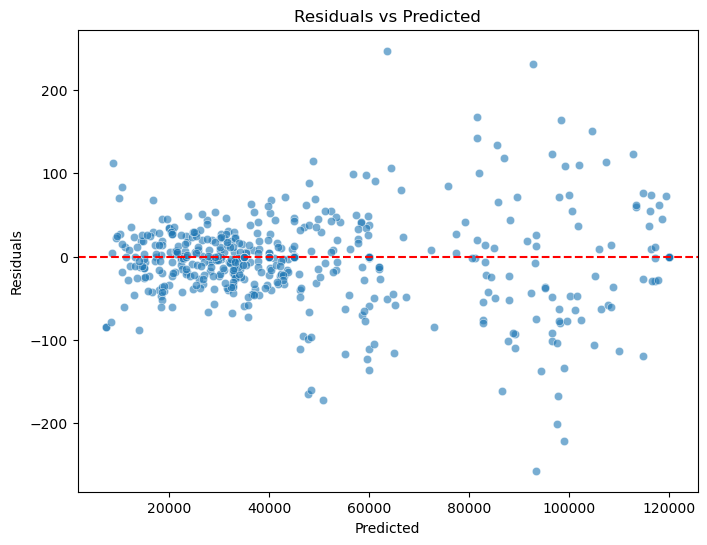

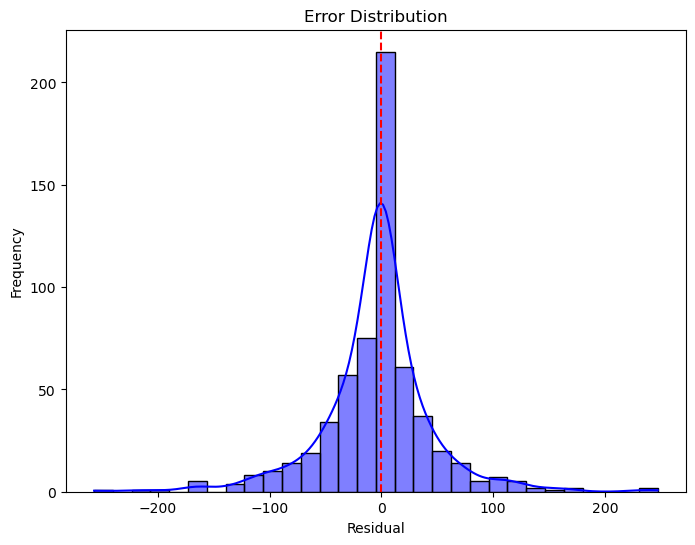

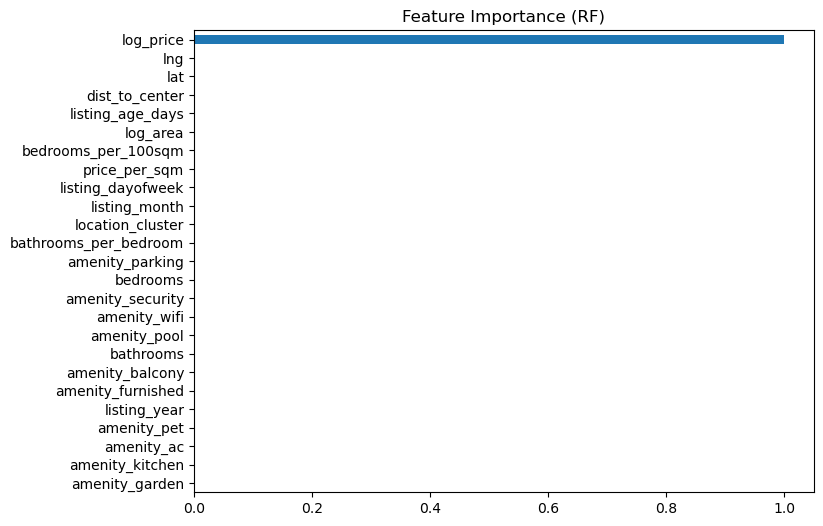

📊 Regression plots saved to images/regression


In [9]:


# Create image folder
images_out = os.path.join("images", "regression")
os.makedirs(images_out, exist_ok=True)

# Residuals plot
y_pred_reg = best_model_reg.predict(X_test)
residuals = y_test - y_pred_reg

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_reg, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.savefig(os.path.join(images_out, "residuals_vs_predicted.png"))
plt.show()

# Error distribution
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.savefig(os.path.join(images_out, "error_distribution.png"))
plt.show()



# Feature Importance
if hasattr(best_model_reg, "feature_importances_"):
    feature_importances = best_model_reg.feature_importances_
    feat_imp = pd.Series(feature_importances, index=X_train.columns)
    feat_imp = feat_imp.sort_values()
    plt.figure(figsize=(8,6))
    feat_imp.plot(kind='barh')
    plt.title(f"Feature Importance ({best_reg})")
    plt.savefig(os.path.join(images_out, "feature_importance.png"), bbox_inches='tight')
    plt.show()

print("📊 Regression plots saved to", images_out)


## Classification modeling (availability)
Logistic baseline, RandomForest, XGBoost, and VotingClassifier.

In [10]:

# Classification — RandomizedSearchCV + Evaluation + Feature Importance

# Ensure X and y_clf exist
if 'X' not in globals() or 'y_clf' not in globals():
    raise RuntimeError("X and y_clf must be defined before running this cell (run your data-prep cells).")

# Split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Logistic Regression baseline
pipe_log = Pipeline([('scaler', StandardScaler()), ('log', LogisticRegression(max_iter=400))])
pipe_log.fit(Xc_train, yc_train)

# Random Forest: corrected max_features values
rfc = RandomForestClassifier(random_state=42)
rfc_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}
rs_rfc = RandomizedSearchCV(rfc, rfc_param_dist, n_iter=30, cv=3, scoring='f1', n_jobs=-1, random_state=42, verbose=1)
rs_rfc.fit(Xc_train, yc_train)
best_rfc = rs_rfc.best_estimator_
print('Best RFC params:', rs_rfc.best_params_)

# XGBoost randomized search
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgbc_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
rs_xgbc = RandomizedSearchCV(xgb_clf, xgbc_param_dist, n_iter=30, cv=3, scoring='f1', n_jobs=-1, random_state=42, verbose=1)
rs_xgbc.fit(Xc_train, yc_train)
best_xgbc = rs_xgbc.best_estimator_
print('Best XGB params:', rs_xgbc.best_params_)

# Voting Classifier (keep Logistic in ensemble for classification)
voting_clf = VotingClassifier(
    estimators=[('rfc', best_rfc), ('xgb', best_xgbc), ('log', pipe_log.named_steps['log'])],
    voting='soft'
)
voting_clf.fit(Xc_train, yc_train)

# Predictions
p_log = pipe_log.predict(Xc_test)
p_rfc = best_rfc.predict(Xc_test)
p_xgbc = best_xgbc.predict(Xc_test)
p_vc = voting_clf.predict(Xc_test)

# Metrics
metrics_map = {
    'Logistic': {
        'f1': f1_score(yc_test, p_log, zero_division=0),
        'precision': precision_score(yc_test, p_log, zero_division=0),
        'recall': recall_score(yc_test, p_log, zero_division=0),
        'accuracy': accuracy_score(yc_test, p_log)
    },
    'RFC': {
        'f1': f1_score(yc_test, p_rfc, zero_division=0),
        'precision': precision_score(yc_test, p_rfc, zero_division=0),
        'recall': recall_score(yc_test, p_rfc, zero_division=0),
        'accuracy': accuracy_score(yc_test, p_rfc)
    },
    'XGB': {
        'f1': f1_score(yc_test, p_xgbc, zero_division=0),
        'precision': precision_score(yc_test, p_xgbc, zero_division=0),
        'recall': recall_score(yc_test, p_xgbc, zero_division=0),
        'accuracy': accuracy_score(yc_test, p_xgbc)
    },
    'Voting': {
        'f1': f1_score(yc_test, p_vc, zero_division=0),
        'precision': precision_score(yc_test, p_vc, zero_division=0),
        'recall': recall_score(yc_test, p_vc, zero_division=0),
        'accuracy': accuracy_score(yc_test, p_vc)
    }
}

print('\nClassification performance (test set):')
print(metrics_map)

# Persist classification models & metrics
models_out = os.path.join("models", "classification")
os.makedirs(models_out, exist_ok=True)

best_clf_name = max(metrics_map, key=lambda k: metrics_map[k]['f1'])
best_clf = {'Logistic': pipe_log, 'RFC': best_rfc, 'XGB': best_xgbc, 'Voting': voting_clf}[best_clf_name]

joblib.dump(voting_clf, os.path.join(models_out, 'bundled_model_classification.pkl'))
joblib.dump(best_clf, os.path.join(models_out, 'best_model_classification.pkl'))

with open(os.path.join(models_out, 'classification_metrics.json'), 'w') as f:
    json.dump({'scores': metrics_map, 'best': best_clf_name}, f, indent=2)

print('\n✅ Classification models saved to', models_out)



Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best RFC params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10, 'bootstrap': True}
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:29:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:29:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:29:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:29:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best XGB params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:29:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 400 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification performance (test set):
{'Logistic': {'f1': 0.9753914988814317, 'precision': 0.9519650655021834, 'recall': 1.0, 'accuracy': 0.9633333333333334}, 'RFC': {'f1': 0.9819819819819819, 'precision': 0.9646017699115044, 'recall': 1.0, 'accuracy': 0.9733333333333334}, 'XGB': {'f1': 0.9875424688561721, 'precision': 0.9753914988814317, 'recall': 1.0, 'accuracy': 0.9816666666666667}, 'Voting': {'f1': 0.9864253393665159, 'precision': 0.9732142857142857, 'recall': 1.0, 'accuracy': 0.98}}

✅ Classification models saved to models/classification


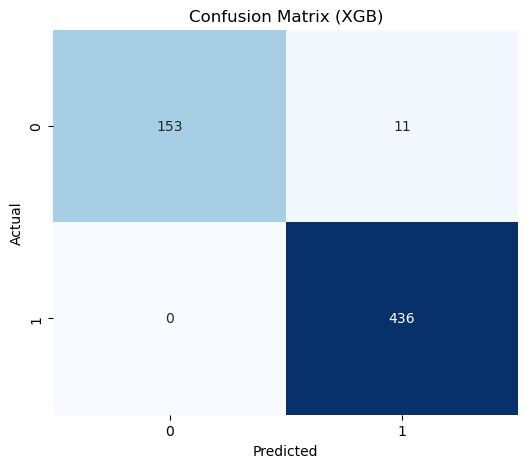

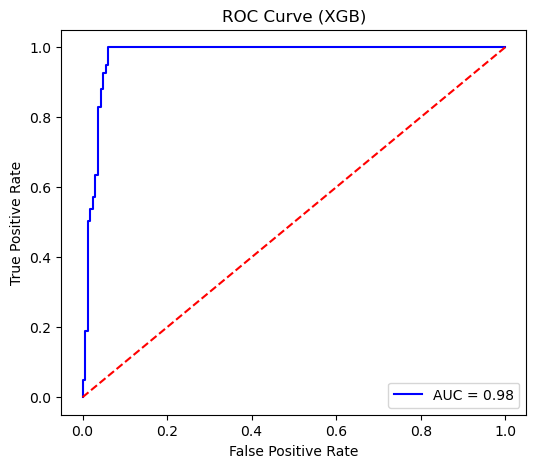

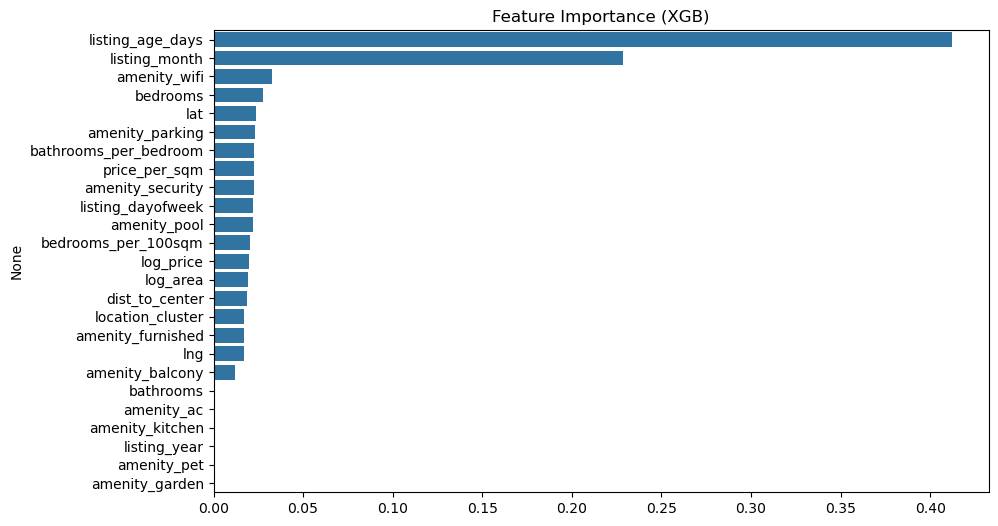


📊 Classification plots saved to images/classification


In [11]:
# Confusion Matrix, ROC, Feature Importance
# Create image folder
images_out = os.path.join("images", "classification")
os.makedirs(images_out, exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(yc_test, best_clf.predict(Xc_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({best_clf_name})")
plt.savefig(os.path.join(images_out, "confusion_matrix.png"), bbox_inches='tight')
plt.show()

# ROC Curve (binary only)
if len(set(yc_test)) == 2 and hasattr(best_clf, "predict_proba"):
    y_prob = best_clf.predict_proba(Xc_test)[:,1]
    fpr, tpr, _ = roc_curve(yc_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1], color='red', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({best_clf_name})")
    plt.legend()
    plt.savefig(os.path.join(images_out, "roc_curve.png"), bbox_inches='tight')
    plt.show()

# Feature Importance (if available)
if hasattr(best_clf, "feature_importances_"):
    importances = best_clf.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10,6))
    sns.barplot(x=importances[indices], y=X.columns[indices])
    plt.title(f"Feature Importance ({best_clf_name})")
    plt.savefig(os.path.join(images_out, "feature_importance.png"), bbox_inches='tight')
    plt.show()

print("\n📊 Classification plots saved to", images_out)


# Auto Report Generator (docs/model_report.md)

In [12]:

def generate_report(
    y_reg_test, y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_vr,
    yc_test, y_pred_lr_clf, y_pred_rf_clf, y_pred_xgb_clf,
    out_dir="docs", out_file="model_report.md"
):
    """
    Generate a markdown report for regression and classification results.
    Saves to docs/model_report.md by default.
    """

    # -------------------------
    # 📊 Regression Metrics
    # -------------------------
    regression_results = {
        "Linear": {
            "rmse": np.sqrt(mean_squared_error(y_reg_test, y_pred_lr)),
            "mae": mean_absolute_error(y_reg_test, y_pred_lr),
            "r2": r2_score(y_reg_test, y_pred_lr),
        },
        "RF": {
            "rmse": np.sqrt(mean_squared_error(y_reg_test, y_pred_rf)),
            "mae": mean_absolute_error(y_reg_test, y_pred_rf),
            "r2": r2_score(y_reg_test, y_pred_rf),
        },
        "XGB": {
            "rmse": np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb)),
            "mae": mean_absolute_error(y_reg_test, y_pred_xgb),
            "r2": r2_score(y_reg_test, y_pred_xgb),
        },
        "Ensemble": {
            "rmse": np.sqrt(mean_squared_error(y_reg_test, y_pred_vr)),
            "mae": mean_absolute_error(y_reg_test, y_pred_vr),
            "r2": r2_score(y_reg_test, y_pred_vr),
        },
    }

    best_reg = min(regression_results, key=lambda k: regression_results[k]["rmse"])
    best_reg_metrics = regression_results[best_reg]

    # -------------------------
    # 📊 Classification Metrics
    # -------------------------
    f1_map = {
        "Logistic Regression": f1_score(yc_test, y_pred_lr_clf, average="weighted"),
        "Random Forest": f1_score(yc_test, y_pred_rf_clf, average="weighted"),
        "XGBoost": f1_score(yc_test, y_pred_xgb_clf, average="weighted"),
    }

    best_clf_name = max(f1_map, key=f1_map.get)
    best_clf_score = f1_map[best_clf_name]

    # -------------------------
    # 📑 Generate Report
    # -------------------------
    os.makedirs(out_dir, exist_ok=True)
    report_path = os.path.join(out_dir, out_file)

    with open(report_path, "w") as f:
        f.write("# 📑 HomeMatch Model Report\n\n")

        # -------------------------
        # 🏆 Overall Summary
        # -------------------------
        f.write("## 🏆 Overall Best Models\n")
        f.write(f"- **Regression:** {best_reg} → RMSE = {best_reg_metrics['rmse']:.4f}, "
                f"MAE = {best_reg_metrics['mae']:.4f}, R² = {best_reg_metrics['r2']:.4f}\n")
        f.write(f"- **Classification:** {best_clf_name} → F1 Score = {best_clf_score:.4f}\n\n")

        # -------------------------
        # Regression Section
        # -------------------------
        f.write("## 🔹 Regression Results\n")
        f.write(f"- **Best Model:** {best_reg}\n\n")

        f.write("### Metrics\n")
        f.write("| Model | RMSE | MAE | R² |\n")
        f.write("|-------|------|-----|----|\n")
        for model_name, m in regression_results.items():
            f.write(f"| {model_name} | {m['rmse']:.4f} | {m['mae']:.4f} | {m['r2']:.4f} |\n")
        f.write("\n")

        f.write("### Plots\n")
        f.write(f"- [Residuals vs Predicted](../images/regression/residuals_vs_predicted.png)\n")
        f.write(f"- [Error Distribution](../images/regression/error_distribution.png)\n\n")

        # -------------------------
        # Classification Section
        # -------------------------
        f.write("## 🔹 Classification Results\n")
        f.write(f"- **Best Model:** {best_clf_name}\n\n")

        f.write("### Metrics\n")
        f.write("| Model | F1 Score |\n")
        f.write("|-------|----------|\n")
        for model_name, score in f1_map.items():
            f.write(f"| {model_name} | {score:.4f} |\n")
        f.write("\n")

        f.write("### Plots\n")
        f.write(f"- [Confusion Matrix](../images/classification/confusion_matrix.png)\n")
        if len(set(yc_test)) == 2:  # binary classification check
            f.write(f"- [ROC Curve](../images/classification/roc_curve.png)\n")

    print("✅ Report generated at", report_path)


# Generate Word Report (docs/model_report.docx)

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
import numpy as np
from docx import Document
from docx.shared import Inches
import os

def generate_report(
    y_reg_test, y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_vr,
    yc_test, y_pred_lr_clf, y_pred_rf_clf, y_pred_xgb_clf,
    out_dir="docs", out_file="model_report.md"
):
    # -------------------------
    # Regression Metrics
    # -------------------------
    regression_results = {
        "Linear": {
            "rmse": np.sqrt(mean_squared_error(y_reg_test, y_pred_lr)),
            "mae": mean_absolute_error(y_reg_test, y_pred_lr),
            "r2": r2_score(y_reg_test, y_pred_lr),
        },
        "RF": {
            "rmse": np.sqrt(mean_squared_error(y_reg_test, y_pred_rf)),
            "mae": mean_absolute_error(y_reg_test, y_pred_rf),
            "r2": r2_score(y_reg_test, y_pred_rf),
        },
        "XGB": {
            "rmse": np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb)),
            "mae": mean_absolute_error(y_reg_test, y_pred_xgb),
            "r2": r2_score(y_reg_test, y_pred_xgb),
        },
        "Ensemble": {
            "rmse": np.sqrt(mean_squared_error(y_reg_test, y_pred_vr)),
            "mae": mean_absolute_error(y_reg_test, y_pred_vr),
            "r2": r2_score(y_reg_test, y_pred_vr),
        },
    }

    best_reg = min(regression_results, key=lambda k: regression_results[k]["rmse"])
    best_reg_metrics = regression_results[best_reg]

    # -------------------------
    # Classification Metrics
    # -------------------------
    f1_map = {
        "Logistic Regression": f1_score(yc_test, y_pred_lr_clf, average="weighted"),
        "Random Forest": f1_score(yc_test, y_pred_rf_clf, average="weighted"),
        "XGBoost": f1_score(yc_test, y_pred_xgb_clf, average="weighted"),
    }

    best_clf_name = max(f1_map, key=f1_map.get)
    best_clf_score = f1_map[best_clf_name]

    # -------------------------
    # Markdown Report
    # -------------------------
    os.makedirs(out_dir, exist_ok=True)
    report_path = os.path.join(out_dir, out_file)

    with open(report_path, "w") as f:
        f.write("# 📑 HomeMatch Model Report\n\n")
        f.write("## 🏆 Overall Best Models\n")
        f.write(f"- **Regression:** {best_reg} → RMSE = {best_reg_metrics['rmse']:.4f}, "
                f"MAE = {best_reg_metrics['mae']:.4f}, R² = {best_reg_metrics['r2']:.4f}\n")
        f.write(f"- **Classification:** {best_clf_name} → F1 Score = {best_clf_score:.4f}\n\n")

    print("✅ Markdown report generated at", report_path)

    # -------------------------
    # Word Report
    # -------------------------
    docs_out = out_dir
    doc = Document()
    doc.add_heading("📑 HomeMatch Model Report", 0)

    # Regression Section
    doc.add_heading("🔹 Regression Results", level=1)
    doc.add_paragraph(f"Best Model: {best_reg} → RMSE = {best_reg_metrics['rmse']:.4f}, "
                      f"MAE = {best_reg_metrics['mae']:.4f}, R² = {best_reg_metrics['r2']:.4f}")

    doc.add_heading("Metrics", level=2)
    table = doc.add_table(rows=1, cols=4)
    hdr_cells = table.rows[0].cells
    hdr_cells[0].text = "Model"
    hdr_cells[1].text = "RMSE"
    hdr_cells[2].text = "MAE"
    hdr_cells[3].text = "R²"

    for model_name, m in regression_results.items():
        row_cells = table.add_row().cells
        row_cells[0].text = model_name
        row_cells[1].text = f"{m['rmse']:.4f}"
        row_cells[2].text = f"{m['mae']:.4f}"
        row_cells[3].text = f"{m['r2']:.4f}"

    doc.add_heading("Plots", level=2)
    regression_images = [
        ("Residuals vs Predicted", "images/regression/residuals_vs_predicted.png"),
        ("Error Distribution", "images/regression/error_distribution.png"),
    ]
    for title, path in regression_images:
        if os.path.exists(path):
            doc.add_paragraph(title)
            doc.add_picture(path, width=Inches(5))

    # Classification Section
    doc.add_heading("🔹 Classification Results", level=1)
    doc.add_paragraph(f"Best Model: {best_clf_name} → F1 Score = {best_clf_score:.4f}")

    doc.add_heading("Metrics", level=2)
    table = doc.add_table(rows=1, cols=2)
    hdr_cells = table.rows[0].cells
    hdr_cells[0].text = "Model"
    hdr_cells[1].text = "F1 Score"

    for model_name, score in f1_map.items():
        row_cells = table.add_row().cells
        row_cells[0].text = model_name
        row_cells[1].text = f"{score:.4f}"

    doc.add_heading("Plots", level=2)
    clf_images = [
        ("Confusion Matrix", "images/classification/confusion_matrix.png"),
        ("ROC Curve", "images/classification/roc_curve.png"),
    ]
    for title, path in clf_images:
        if os.path.exists(path):
            doc.add_paragraph(title)
            doc.add_picture(path, width=Inches(5))

    # Save DOCX
    doc_path = os.path.join(docs_out, "model_report.docx")
    doc.save(doc_path)

    print("✅ Word report generated at", doc_path)


In [14]:
print(df.columns.tolist())

['listing_id', 'city', 'location_name', 'latitude', 'longitude', 'property_type', 'price_ksh', 'bedrooms', 'bathrooms', 'area_size_sqm', 'availability_status', 'available_from', 'amenities', 'date_listed', 'image_url', 'price_per_sqm', 'bedrooms_per_100sqm', 'bathrooms_per_bedroom', 'log_area', 'log_price', 'listing_year', 'listing_month', 'listing_dayofweek', 'listing_age_days', 'lat', 'lng', 'location_cluster', 'dist_to_center', 'amenity_wifi', 'amenity_parking', 'amenity_furnished', 'amenity_pet', 'amenity_pool', 'amenity_ac', 'amenity_balcony', 'amenity_kitchen', 'amenity_security', 'amenity_garden', 'price', 'availability_bool']



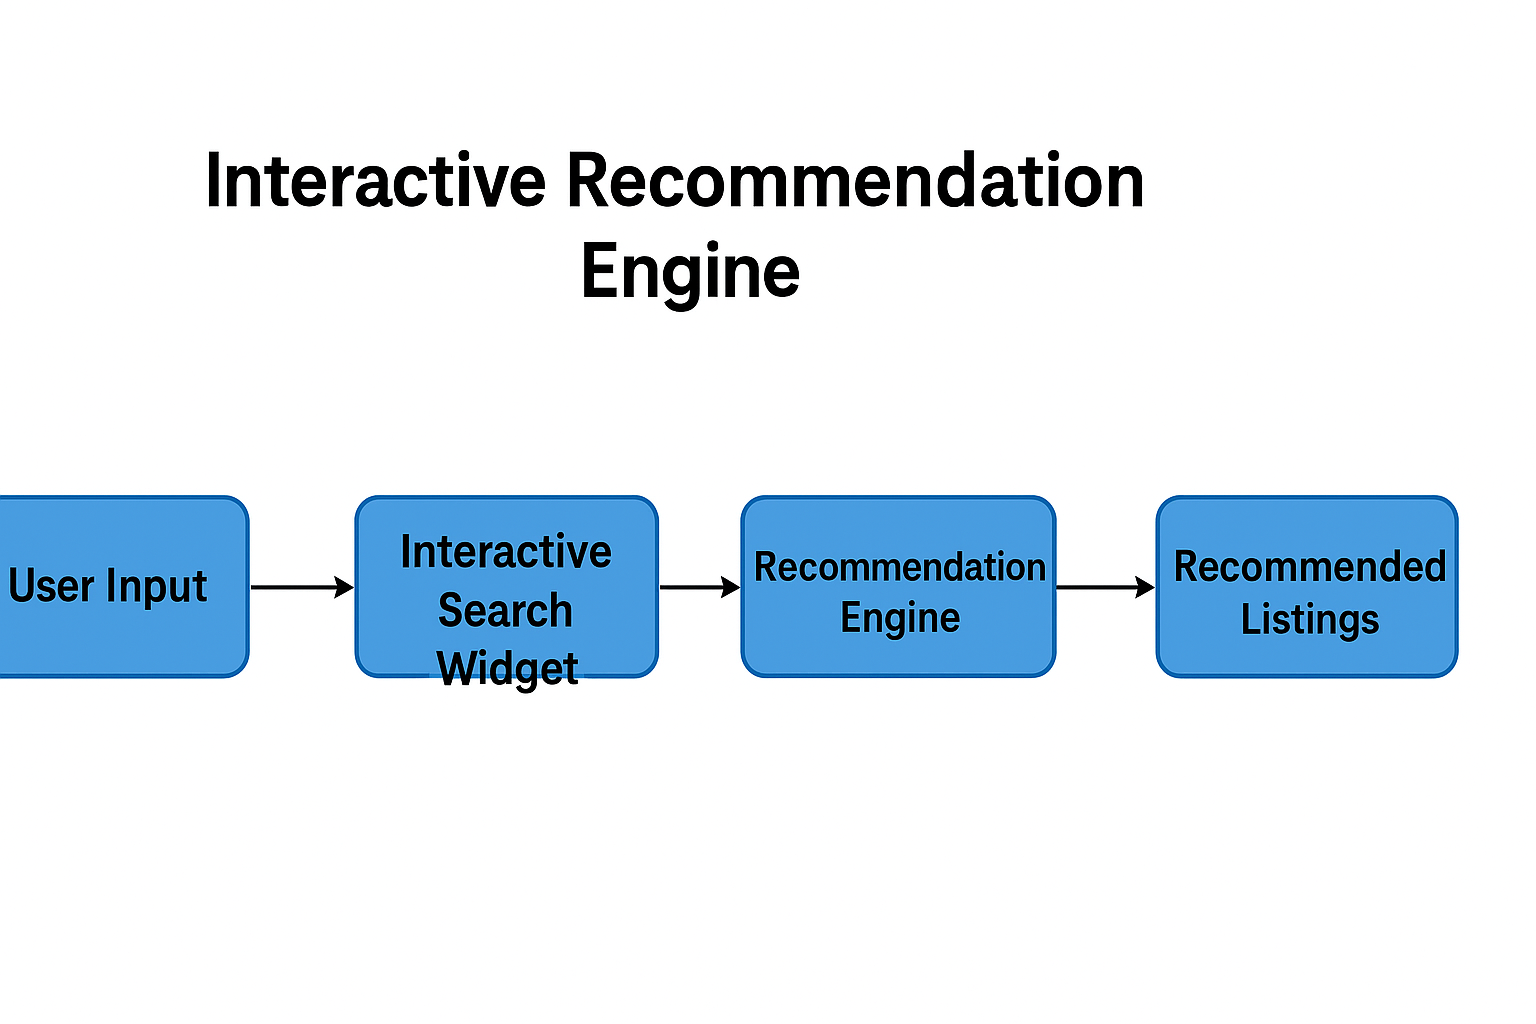










## Interactive Search & Recommendation Demo (Widgets)

### Dynamic Text-Based Recommendation Engine

This module implements a dynamic content-based recommendation system using TF-IDF vectorization and cosine similarity for keyword-based searches. It is designed to:
Automatically build a TF-IDF matrix from specified text columns.
Perform keyword-based recommendations using semantic similarity.
Log progress and missing columns if debug mode is enabled.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import ipywidgets as widgets

# Combine property info into a single text field safely
text_field = df[['property_type', 'location_name', 'amenities']] \
    .fillna('') \
    .astype(str) \
    .agg(' '.join, axis=1)

# Build TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=20000)
tfidf_matrix = vectorizer.fit_transform(text_field)

# Recommendation function
def recommend_by_text(df_in, query, top_n=5, tfidf=tfidf_matrix, vec=vectorizer):
    if tfidf is None:
        raise RuntimeError("TF-IDF matrix not available")
    q_vec = vec.transform([str(query)])
    sims = cosine_similarity(q_vec, tfidf).flatten()
    top_idx = sims.argsort()[-top_n:][::-1]
    return df_in.iloc[top_idx].reset_index(drop=True)


# Interactive Filtering and Hybrid Recommendation UI

This code implements an interactive widget-based interface for filtering a dataset and generating hybrid recommendations using IPython widgets.It allows users to dynamically:
*Add and clear filter conditions
*Filter dataset rows
*Search by keyword and location
*Set search parameters
*Display results dynamically



In [16]:
condition_rows = []
conditions_box = widgets.VBox()
out = widgets.Output()

lat_input = widgets.FloatText(description='Latitude:')
lon_input = widgets.FloatText(description='Longitude:')
top_k_input = widgets.IntText(value=5, description='Top K:')
kw_input = widgets.Text(description='Keyword:')

btn_add = widgets.Button(description='➕ Add Condition', button_style='success')
btn_clear = widgets.Button(description='🗑️ Clear Conditions', button_style='warning')
btn_search = widgets.Button(description='🔍 Search', button_style='primary')

def create_condition_row():
    feature = widgets.Dropdown(options=df.columns.tolist(), description='Feature:')
    cond = widgets.Dropdown(options=['==', '<', '>', '<=', '>='], description='Cond:')
    val = widgets.Text(description='Value:')
    return widgets.HBox([feature, cond, val])

def add_condition(_):
    row = create_condition_row()
    condition_rows.append(row)
    conditions_box.children = condition_rows

def clear_conditions(_):
    condition_rows.clear()
    conditions_box.children = []

def run_demo(_):
    with out:
        clear_output()
        q_df = df.copy()
        for row in condition_rows:
            f, c, v = row.children
            if v.value.strip():
                try:
                    val = float(v.value) if v.value.replace('.','',1).isdigit() else v.value
                except:
                    val = v.value
                if c.value == '==':
                    q_df = q_df[q_df[f.value].astype(str).str.contains(str(val), case=False, na=False)]
                else:
                    try:
                        if c.value == '<': q_df = q_df[q_df[f.value] < float(val)]
                        if c.value == '>': q_df = q_df[q_df[f.value] > float(val)]
                        if c.value == '<=': q_df = q_df[q_df[f.value] <= float(val)]
                        if c.value == '>=': q_df = q_df[q_df[f.value] >= float(val)]
                    except Exception as e:
                        print('Filter error:', e)
        if lat_input.value and lon_input.value:
            try:
                recs = recommend_hybrid(q_df, user_lat=lat_input.value, user_lon=lon_input.value, keyword=kw_input.value or None, top_n=top_k_input.value)
                display(recs)
                print(f'✅ Showing top {len(recs)} hybrid recommendations (filtered).')
            except Exception as e:
                print('Recommendation error:', e)
        else:
            if kw_input.value.strip():
                recs = recommend_by_text(q_df, kw_input.value, top_n=top_k_input.value)
                display(recs)
                print(f'✅ Showing top {len(recs)} content-based recommendations (filtered).')
            else:
                display(q_df.head(10))
                print('✅ Showing filtered results (no recommendations - provide keyword or coordinates for recommendations).')

btn_add.on_click(add_condition)
btn_clear.on_click(clear_conditions)
btn_search.on_click(run_demo)

ui = widgets.VBox([widgets.HBox([btn_add, btn_clear, btn_search]), conditions_box, widgets.HBox([lat_input, lon_input, top_k_input, kw_input]), out])

display(ui)

## Distance-Based Recommendation (Haversine)

In [17]:
import numpy as np

def haversine_vectorized(lat1, lon1, lat2_array, lon2_array):
    R = 6371.0
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2_array)
    lon2_rad = np.radians(lon2_array)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c


def find_nearest(df_in, lat, lon, k=5, lat_col='latitude', lon_col='longitude'):
    df_local = df_in.copy()
    if lat_col not in df_local.columns or lon_col not in df_local.columns:
        raise ValueError('latitude/longitude columns required for find_nearest')
    mask = df_local[lat_col].notna() & df_local[lon_col].notna()
    candidates = df_local[mask].copy()
    distances = haversine_vectorized(lat, lon, candidates[lat_col].values, candidates[lon_col].values)
    candidates['distance_km'] = distances
    candidates = candidates.sort_values(by='distance_km')
    return candidates.head(k).reset_index(drop=True)


## Content-Based Recommendation (TF-IDF + Cosine Similarity)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def build_tfidf_matrix(df, cols_to_combine=None, max_features=20000, debug=True):
    """
    Builds a TF-IDF matrix from specified columns.
    Automatically ignores missing columns and logs missing ones if debug=True.
    """
    if cols_to_combine is None:
        cols_to_combine = ['description', 'name', 'property_type', 'location_name', 'amenities']

    # Check which columns exist
    existing_cols = [col for col in cols_to_combine if col in df.columns]
    missing_cols = [col for col in cols_to_combine if col not in df.columns]

    if debug and missing_cols:
        print(f"⚠️ Warning: Missing columns ignored: {missing_cols}")

    if not existing_cols:
        raise ValueError("❌ None of the specified columns exist in the dataframe.")

    # Combine text fields safely
    text_field = df[existing_cols].fillna('').astype(str).agg(' '.join, axis=1)

    if debug:
        print(f"✅ Building TF-IDF matrix using columns: {existing_cols}")
        print(f"Sample combined text:\n{text_field.head(3)}\n")

    # Build TF-IDF
    vectorizer = TfidfVectorizer(stop_words='english', max_features=max_features)
    tfidf_matrix = vectorizer.fit_transform(text_field)

    return tfidf_matrix, vectorizer

def recommend_by_text(df, query, cols_to_combine=None, top_n=5, tfidf_matrix=None, vectorizer=None, debug=True):
    """
    Returns top N recommendations based on text similarity.
    If TF-IDF matrix or vectorizer is missing, builds them dynamically.
    Logs info if debug=True.
    """
    if tfidf_matrix is None or vectorizer is None:
        if debug:
            print("ℹ️ TF-IDF matrix/vectorizer not provided — building dynamically.")
        tfidf_matrix, vectorizer = build_tfidf_matrix(df, cols_to_combine, debug=debug)

    if debug:
        print(f"🔍 Querying: {query}")

    q_vec = vectorizer.transform([str(query)])
    sims = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_idx = sims.argsort()[-top_n:][::-1]

    if debug:
        print(f"📌 Top {top_n} similarity scores: {sims[top_idx]}")

    return df.iloc[top_idx].reset_index(drop=True)


# Example usage:
cols_to_use = ['description', 'name', 'property_type', 'location_name', 'amenities']

tfidf_matrix, vectorizer = build_tfidf_matrix(df, cols_to_use, debug=True)
recommendations = recommend_by_text(df, "spacious apartment with pool", cols_to_use, top_n=5, tfidf_matrix=tfidf_matrix, vectorizer=vectorizer, debug=True)

print(recommendations)


⚠️ Warning: Missing columns ignored: ['description', 'name']
✅ Building TF-IDF matrix using columns: ['property_type', 'location_name', 'amenities']
Sample combined text:
0    3.0 22.0 balcony, parking, pool, gym, furnishe...
1                              4.0 18.0 water, balcony
2                                   0.0 15.0 gym, pool
dtype: object

🔍 Querying: spacious apartment with pool
📌 Top 5 similarity scores: [0.71213653 0.71213653 0.71213653 0.71213653 0.7119856 ]
  listing_id     city  location_name  latitude  longitude  property_type  \
0    HM01604   Nakuru            2.0 -0.272900  36.059730            0.0   
1    HM00325   Nakuru            9.0 -0.311713  36.103498            4.0   
2    HM00108  Nairobi            0.0 -1.302318  36.804370            3.0   
3    HM00700   Nakuru            9.0 -0.289097  36.093378            5.0   
4    HM00558  Nairobi            6.0 -1.239275  36.800238            5.0   

   price_ksh  bedrooms  bathrooms  area_size_sqm availability_statu

## Hybrid Recommendation (Distance + Content)

In [19]:
def recommend_hybrid(df_in, user_lat=None, user_lon=None, keyword=None, top_n=5, weight_distance=0.5, weight_text=0.5):
    candidates = df_in.copy()
    if user_lat is not None and user_lon is not None and 'latitude' in candidates.columns:
        mask = candidates['latitude'].notna() & candidates['longitude'].notna()
        dist = np.full(len(candidates), np.nan)
        dist[mask] = haversine_vectorized(user_lat, user_lon, candidates.loc[mask,'latitude'].values, candidates.loc[mask,'longitude'].values)
        dist_score = np.nan_to_num(1 / (1 + dist))
        if dist_score.max() > 0:
            dist_score = (dist_score - dist_score.min()) / (dist_score.max() - dist_score.min())
    else:
        dist_score = np.zeros(len(candidates))

    if keyword and tfidf_matrix is not None:
        q_vec = vectorizer.transform([str(keyword)])
        text_sims = cosine_similarity(q_vec, tfidf_matrix).flatten()
        if text_sims.max() > 0:
            text_sims = (text_sims - text_sims.min()) / (text_sims.max() - text_sims.min())
    else:
        text_sims = np.zeros(len(candidates))

    combined = weight_distance * dist_score + weight_text * text_sims
    candidates['hybrid_score'] = combined
    return candidates.sort_values('hybrid_score', ascending=False).head(top_n).reset_index(drop=True)


# HybridRecommender Class — Hybrid Numeric & Text-Based Recommendation System

The HybridRecommender class implements a hybrid recommendation engine that combines numeric feature similarity and textual content similarity to produce ranked recommendations. It is designed for datasets containing both numerical attributes and descriptive text fields, such as real estate listings.

In [20]:

# HybridRecommender Class 
class HybridRecommender:
    def __init__(self, df, cols_to_combine=None, numeric_cols=None, feat_prefix='amenity_', max_features=20000, debug=True):
        self.df = df
        self.cols_to_combine = cols_to_combine or ['description', 'name', 'property_type', 'location_name', 'amenities']
        self.numeric_cols = numeric_cols or ['bedrooms', 'bathrooms']
        self.feat_prefix = feat_prefix
        self.max_features = max_features
        self.debug = debug

        self._cache = {}
        self.tfidf_matrix = None
        self.vectorizer = None
        self.numeric_matrix = None
        self.numeric_features = None

    def build_tfidf_matrix(self):
        key = f"tfidf_{tuple(self.cols_to_combine)}_{self.max_features}"
        if key in self._cache:
            if self.debug:
                print("ℹ️ Using cached TF-IDF matrix.")
            self.tfidf_matrix, self.vectorizer = self._cache[key]
            return

        existing_cols = [col for col in self.cols_to_combine if col in self.df.columns]
        missing_cols = [col for col in self.cols_to_combine if col not in self.df.columns]

        if self.debug and missing_cols:
            print(f"⚠️ Missing columns ignored: {missing_cols}")

        if not existing_cols:
            raise ValueError("❌ None of the specified columns exist in the dataframe.")

        text_field = self.df[existing_cols].fillna('').astype(str).agg(' '.join, axis=1)

        if self.debug:
            print(f"✅ Building TF-IDF matrix with columns: {existing_cols}")
            print(f"Sample combined text:\n{text_field.head(3)}\n")

        self.vectorizer = TfidfVectorizer(stop_words='english', max_features=self.max_features)
        self.tfidf_matrix = self.vectorizer.fit_transform(text_field)
        self._cache[key] = (self.tfidf_matrix, self.vectorizer)

    def build_numeric_matrix(self):
        key = f"numeric_{self.feat_prefix}_{tuple(self.numeric_cols)}"
        if key in self._cache:
            if self.debug:
                print("ℹ️ Using cached numeric matrix.")
            self.numeric_matrix, self.numeric_features = self._cache[key]
            return

        feat_sim = self.numeric_cols + [c for c in self.df.columns if c.startswith(self.feat_prefix)]
        feat_sim = [col for col in feat_sim if col in self.df.columns]

        if self.debug:
            missing = set(self.numeric_cols + [self.feat_prefix+'*']) - set(feat_sim)
            if missing:
                print(f"⚠️ Missing numeric features: {missing}")

        self.numeric_matrix = self.df[feat_sim].apply(pd.to_numeric, errors="coerce").fillna(0).values
        self.numeric_features = feat_sim
        self._cache[key] = (self.numeric_matrix, self.numeric_features)

    def clear_cache(self):
        self._cache = {}
        if self.debug:
            print("🗑️ Recommendation cache cleared.")

    def recommend(self, listing_index, query=None, top_n=5, alpha=0.5, compact=True, visualize=False):
        if not (0 <= alpha <= 1):
            raise ValueError("Alpha must be between 0 and 1.")

        if self.numeric_matrix is None:
            self.build_numeric_matrix()
        numeric_sim = cosine_similarity(self.numeric_matrix, self.numeric_matrix)[listing_index]

        if query is not None:
            if self.tfidf_matrix is None or self.vectorizer is None:
                self.build_tfidf_matrix()
            q_vec = self.vectorizer.transform([str(query)])
            text_sim = cosine_similarity(q_vec, self.tfidf_matrix).flatten()
        else:
            text_sim = np.zeros(len(self.df))

        hybrid_scores = alpha * numeric_sim + (1 - alpha) * text_sim
        top_idx = hybrid_scores.argsort()[::-1][1:top_n+1]

        if visualize:
            self.visualize_similarity(numeric_sim, text_sim, hybrid_scores, listing_index, query, alpha)

        result = self.df.iloc[top_idx].copy()
        result['similarity_score'] = hybrid_scores[top_idx]
        result['address'] = result.get('city', '').astype(str).fillna('') + " - " + result.get('location_name', '').astype(str).fillna('')
        result['image_link'] = result.get('image_url', '').apply(
            lambda x: f'<a href="{x}" target="_blank">View Image</a>' if pd.notnull(x) else ""
        )

        result.insert(0, 'rank', range(1, len(result)+1))
        result.loc[result['rank'] == 1, 'rank'] = "⭐ Best Match"

        if compact:
            display_cols = ['rank', 'address', 'price_ksh', 'bedrooms', 'bathrooms', 'property_type', 'similarity_score', 'image_link']
        else:
            display_cols = list(self.df.columns) + ['similarity_score', 'image_link']

        return HTML(result[display_cols].to_html(escape=False, index=False))

    def visualize_similarity(self, numeric_sim, text_sim, hybrid_scores, listing_index, query, alpha):
        labels = [f"Listing {i}" for i in range(len(self.df))]
        x = np.arange(len(self.df))

        plt.figure(figsize=(12, 6))
        plt.bar(x - 0.2, numeric_sim, width=0.2, label='Numeric Similarity')
        plt.bar(x, text_sim, width=0.2, label='Text Similarity')
        plt.bar(x + 0.2, hybrid_scores, width=0.2, label=f'Hybrid Similarity (alpha={alpha})')

        plt.xticks(x, labels, rotation=45)
        plt.ylabel("Similarity Score")
        plt.title(f"Similarity Scores for Listing {listing_index} — Query: {query}")
        plt.legend()
        plt.show()

    def plot_alpha_sensitivity(self, listing_index, query, top_n=5):
        if self.numeric_matrix is None:
            self.build_numeric_matrix()
        numeric_sim = cosine_similarity(self.numeric_matrix, self.numeric_matrix)[listing_index]

        if self.tfidf_matrix is None or self.vectorizer is None:
            self.build_tfidf_matrix()
        q_vec = self.vectorizer.transform([str(query)])
        text_sim = cosine_similarity(q_vec, self.tfidf_matrix).flatten()

        alphas = np.linspace(0, 1, 11)
        top_scores = []

        for alpha in alphas:
            hybrid_scores = alpha * numeric_sim + (1 - alpha) * text_sim
            top_idx = hybrid_scores.argsort()[::-1][1:top_n+1]
            top_scores.append(hybrid_scores[top_idx[0]])

        plt.figure(figsize=(10, 5))
        plt.plot(alphas, top_scores, marker='o', color='b')
        plt.xlabel("Alpha (Weight of Numeric Similarity)")
        plt.ylabel("Top Match Hybrid Similarity Score")
        plt.title(f"Alpha Sensitivity — Listing {listing_index}, Query: '{query}'")
        plt.grid(True)
        plt.show()


## Hybrid_Recommender_Data_Loader.md

Load data from either a PostgreSQL database or a CSV fallback.
Cache the dataset for performance.
Build a recommender (numeric + text hybrid) once data is loaded.
Run recommendations with varying alpha values (numeric vs text)

In [22]:
import os
import pickle
import psycopg2
import pandas as pd


class HybridRecommenderLoader:
    def __init__(self, dbname, user, password, host, port, table, csv_path,
                 cache_path="dataset_cache.pkl", timestamp_col="last_updated", debug=True):
        self.dbname = dbname
        self.user = user
        self.password = password
        self.host = host
        self.port = port
        self.table = table
        self.csv_path = csv_path
        self.cache_path = cache_path
        self.timestamp_col = timestamp_col
        self.debug = debug

        self.df = None
        self.refreshed = False
        self.recommender = None

        if not os.path.exists(self.csv_path):
            if self.debug:
                print(f"⚠️ Warning: CSV fallback file '{self.csv_path}' does not exist!")

        self.ensure_timestamp_column()

    def ensure_timestamp_column(self):
        """Ensure the timestamp column exists and auto-update trigger is set."""
        try:
            conn = psycopg2.connect(
                dbname=self.dbname, user=self.user,
                password=self.password, host=self.host, port=self.port
            )
            cur = conn.cursor()

            # Check if timestamp column exists
            cur.execute("""
                SELECT column_name
                FROM information_schema.columns
                WHERE table_name = %s
                  AND column_name = %s;
            """, (self.table, self.timestamp_col))

            if cur.fetchone():
                if self.debug:
                    print(f"ℹ️ Timestamp column '{self.timestamp_col}' exists.")
            else:
                cur.execute(f"""
                    ALTER TABLE {self.table}
                    ADD COLUMN {self.timestamp_col} TIMESTAMP DEFAULT NOW();
                """)
                conn.commit()
                if self.debug:
                    print(f"✅ Added timestamp column '{self.timestamp_col}' to '{self.table}'.")

            # Create trigger function to auto-update timestamp
            cur.execute(f"""
                CREATE OR REPLACE FUNCTION update_{self.timestamp_col}()
                RETURNS TRIGGER AS $$
                BEGIN
                    NEW.{self.timestamp_col} = NOW();
                    RETURN NEW;
                END;
                $$ LANGUAGE plpgsql;
            """)
            conn.commit()

            # Attach trigger if missing
            cur.execute(f"""
                DO $$
                BEGIN
                    IF NOT EXISTS (
                        SELECT 1 FROM pg_trigger WHERE tgname = '{self.table}_{self.timestamp_col}_trigger'
                    ) THEN
                        CREATE TRIGGER {self.table}_{self.timestamp_col}_trigger
                        BEFORE UPDATE ON {self.table}
                        FOR EACH ROW
                        EXECUTE FUNCTION update_{self.timestamp_col}();
                    END IF;
                END;
                $$;
            """)
            conn.commit()

            if self.debug:
                print(f"✅ Trigger set up for '{self.timestamp_col}' on table '{self.table}'.")
            conn.close()

        except Exception as e:
            if self.debug:
                print("⚠️ Could not ensure timestamp column or trigger:", e)

    def db_last_updated_timestamp(self):
        try:
            conn = psycopg2.connect(
                dbname=self.dbname, user=self.user,
                password=self.password, host=self.host, port=self.port
            )
            cur = conn.cursor()
            cur.execute(f"SELECT MAX({self.timestamp_col}) FROM {self.table}")
            latest = cur.fetchone()[0]
            conn.close()
            return latest
        except Exception as e:
            if self.debug:
                print("⚠️ Could not check DB freshness:", e)
            return None

    def load_data(self):
        latest_timestamp = None

        # Try loading from cache first
        if os.path.exists(self.cache_path):
            try:
                with open(self.cache_path, "rb") as f:
                    cached_df, cached_timestamp = pickle.load(f)

                db_timestamp = self.db_last_updated_timestamp()
                if db_timestamp == cached_timestamp:
                    if self.debug:
                        print(f"📦 Loading dataset from CACHE '{self.cache_path}' ✅")
                    self.df = cached_df
                    self.refreshed = False
                    return
                else:
                    if self.debug:
                        print("🔄 Database change detected — refreshing cache.")
            except Exception as e:
                if self.debug:
                    print("⚠️ Error reading cache:", e)

        # Try loading from DB
        try:
            conn = psycopg2.connect(
                dbname=self.dbname, user=self.user,
                password=self.password, host=self.host, port=self.port
            )
            if self.debug:
                print(f"🔗 Connected to database '{self.dbname}' ✅")
            self.df = pd.read_sql(f"SELECT * FROM {self.table}", conn)
            cur = conn.cursor()
            cur.execute(f"SELECT MAX({self.timestamp_col}) FROM {self.table}")
            latest_timestamp = cur.fetchone()[0]
            conn.close()
            if self.debug:
                print(f"📦 Loaded dataset from DATABASE '{self.table}' ✅")
        except Exception as e:
            if self.debug:
                print("⚠️ Database not available:", e)
            if os.path.exists(self.csv_path):
                if self.debug:
                    print(f"📄 Loading CSV fallback from '{self.csv_path}' ✅")
                self.df = pd.read_csv(self.csv_path)
                latest_timestamp = None
            else:
                raise FileNotFoundError(f"No dataset found.\nTried DB '{self.dbname}.{self.table}' and CSV at '{self.csv_path}'")

        # Cache dataset
        with open(self.cache_path, "wb") as f:
            pickle.dump((self.df, latest_timestamp), f)
        if self.debug:
            print(f"💾 Dataset cached to '{self.cache_path}' ✅")

        self.refreshed = True

    def build_recommender(self, recommender_class):
        if self.df is None:
            raise ValueError("Dataset not loaded. Call load_data() first.")
        self.recommender = recommender_class(self.df, debug=self.debug)
        if self.refreshed:
            if self.debug:
                print("📌 Dataset refreshed — rebuilding numeric and text matrices...")
            self.recommender.build_numeric_matrix()
            self.recommender.build_tfidf_matrix()
        else:
            if self.debug:
                print("ℹ️ Dataset unchanged — using existing matrices if available.")

    def get_recommender(self):
        if self.recommender is None:
            raise ValueError("Recommender not built. Call build_recommender() first.")
        return self.recommender


⚠️ Warning: CSV fallback file '/Users/chebet/Desktop/HomeMatch_Kenya_App/HomeMatch_Kenya_Housing.csv' does not exist!
✅ Added timestamp column 'last_updated' to 'housing_listings'.
✅ Trigger set up for 'last_updated' on table 'housing_listings'.
🔗 Connected to database 'homematch_db' ✅
📦 Loaded dataset from DATABASE 'housing_listings' ✅
💾 Dataset cached to 'dataset_cache.pkl' ✅
✅ Loaded dataset shape: (3000, 16)
📌 Dataset refreshed — rebuilding numeric and text matrices...
⚠️ Missing numeric features: {'amenity_*'}
⚠️ Missing columns ignored: ['description', 'name']
✅ Building TF-IDF matrix with columns: ['property_type', 'location_name', 'amenities']
Sample combined text:
0    Maisonette Nyali Balcony, Parking, Pool, Gym, ...
1                         Studio Mtwapa Water, Balcony
2                        Apartment Lavington Gym, Pool
dtype: object

🔹 Numeric Similarity Only (alpha=1.0)


/var/folders/ht/zbr8w6793p5bxcm924rzym5c0000gn/T/ipykernel_7679/3993704070.py:144: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  self.df = pd.read_sql(f"SELECT * FROM {self.table}", conn)


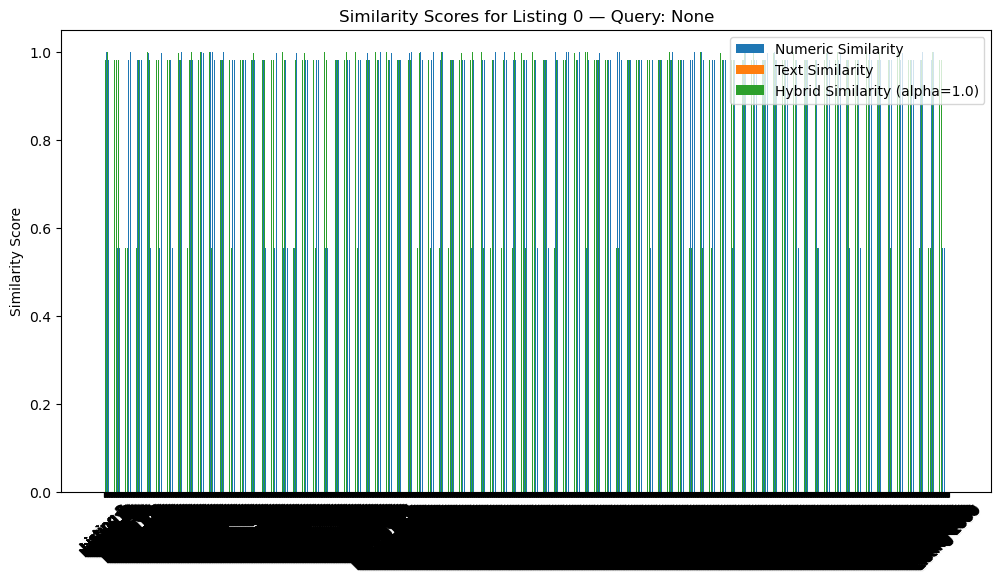

/var/folders/ht/zbr8w6793p5bxcm924rzym5c0000gn/T/ipykernel_7679/2041705519.py:99: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '⭐ Best Match' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  result.loc[result['rank'] == 1, 'rank'] = "⭐ Best Match"


rank,address,price_ksh,bedrooms,bathrooms,property_type,similarity_score,image_link
⭐ Best Match,Nakuru - Kapkures,40000,3,2,Townhouse,1.0,View Image
2,Nairobi - Kileleshwa,87985,3,2,Townhouse,1.0,View Image
3,Nairobi - Lavington,120000,3,2,Bungalow,1.0,View Image


🔹 Text Similarity Only (alpha=0.0)


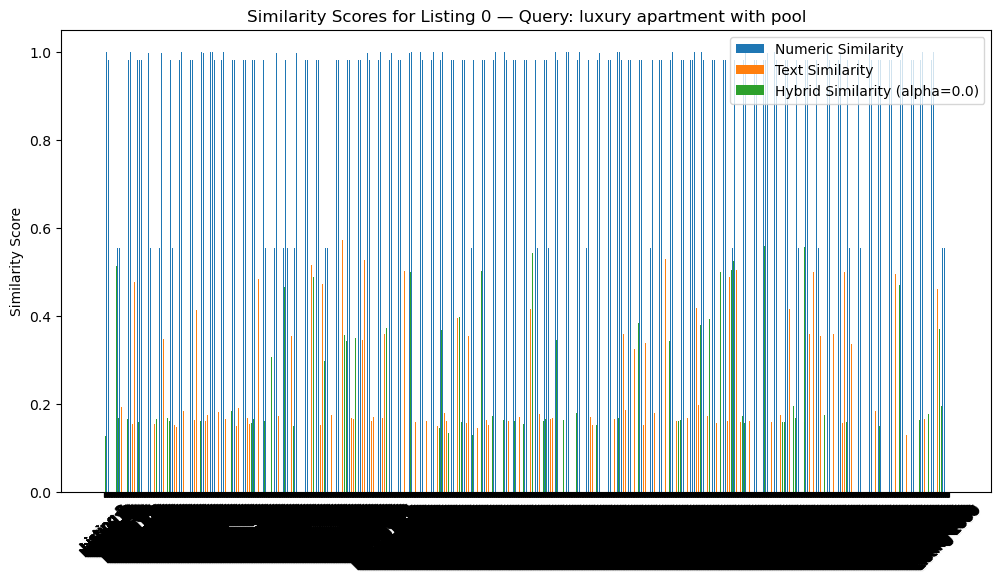

/var/folders/ht/zbr8w6793p5bxcm924rzym5c0000gn/T/ipykernel_7679/2041705519.py:99: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '⭐ Best Match' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  result.loc[result['rank'] == 1, 'rank'] = "⭐ Best Match"


rank,address,price_ksh,bedrooms,bathrooms,property_type,similarity_score,image_link
⭐ Best Match,Nairobi - Lavington,66744,2,2,Apartment,0.609264,View Image
2,Nairobi - Kileleshwa,66414,2,2,Apartment,0.609137,View Image
3,Nakuru - Milimani,26088,4,3,Apartment,0.607234,View Image


🔹 Hybrid Similarity (alpha=0.5)


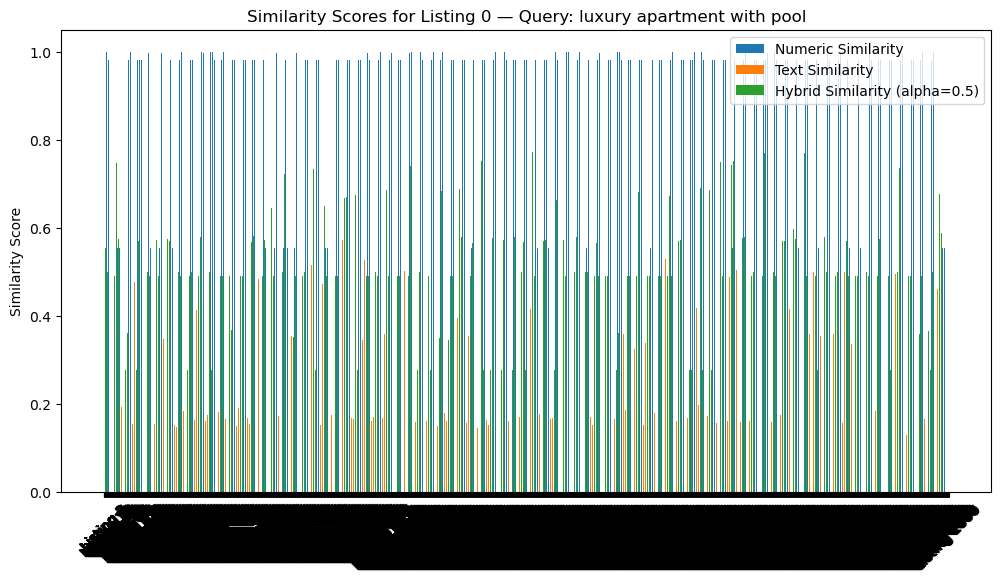

/var/folders/ht/zbr8w6793p5bxcm924rzym5c0000gn/T/ipykernel_7679/2041705519.py:99: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '⭐ Best Match' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  result.loc[result['rank'] == 1, 'rank'] = "⭐ Best Match"


rank,address,price_ksh,bedrooms,bathrooms,property_type,similarity_score,image_link
⭐ Best Match,Nairobi - Dagoretti,108360,3,2,Apartment,0.802373,View Image
2,Nairobi - Riverside,60928,2,2,Apartment,0.795489,View Image
3,Nairobi - Lavington,66744,2,2,Apartment,0.794922,View Image


🔹 Alpha Sensitivity Demonstration


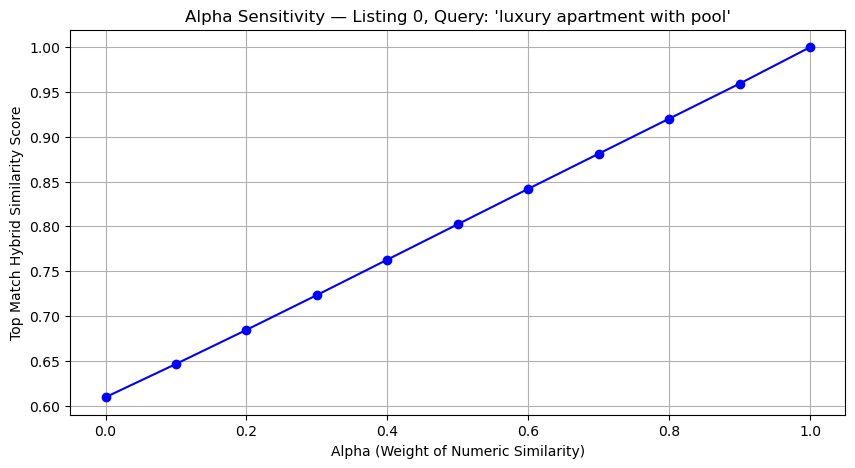

In [23]:
if __name__ == "__main__":
    CSV_FALLBACK = "/Users/chebet/Desktop/HomeMatch_Kenya_App/HomeMatch_Kenya_Housing.csv"

    loader = HybridRecommenderLoader(
        dbname="homematch_db",
        user="chebet",
        password="your_password",
        host="localhost",
        port="5432",
        table="housing_listings",
        csv_path=CSV_FALLBACK,
        timestamp_col="last_updated",
        debug=True
    )

    loader.load_data()  # Will now explicitly print load source
    print("✅ Loaded dataset shape:", loader.df.shape)

    loader.build_recommender(HybridRecommender)
    recommender = loader.get_recommender()

    print("🔹 Numeric Similarity Only (alpha=1.0)")
    display(recommender.recommend(listing_index=0, query=None, top_n=3, alpha=1.0, visualize=True))

    print("🔹 Text Similarity Only (alpha=0.0)")
    display(recommender.recommend(listing_index=0, query="luxury apartment with pool", top_n=3, alpha=0.0, visualize=True))

    print("🔹 Hybrid Similarity (alpha=0.5)")
    display(recommender.recommend(listing_index=0, query="luxury apartment with pool", top_n=3, alpha=0.5, visualize=True))

    print("🔹 Alpha Sensitivity Demonstration")
    recommender.plot_alpha_sensitivity(listing_index=0, query="luxury apartment with pool", top_n=3)



Bar charts showing numeric similarity, text similarity, and hybrid similarity side-by-side.
Alpha effect — changing alpha changes the hybrid similarity weights, visible in the chart.
Query effect — shows the impact of different queries.

## Streamlit integration
Paste code into `streamlit_app/app.py` or use the provided app to load saved models and predict live.

In [24]:
# 🔥 Auto-generate / update full-featured Streamlit app.py with images on map
app_code = """
import streamlit as st
import pandas as pd
import folium
from streamlit_folium import st_folium
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from math import radians, sin, cos, sqrt, atan2

# === Load Data ===
@st.cache_data
def load_data():
    return pd.read_csv("HomeMatch_Kenya_Housing.csv")

df = load_data()

# === Distance Function ===
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def find_nearest(lat, lon, k=5):
    temp = df.copy()
    temp['distance_km'] = temp.apply(
        lambda r: haversine(lat, lon, r['latitude'], r['longitude']), axis=1
    )
    return temp.sort_values('distance_km').head(k)

# === TF-IDF Recommender ===
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(
    df['description'].fillna('') + " " + df['name'].fillna('')
)

def recommend_by_text(query, top_n=5):
    query_vec = vectorizer.transform([str(query)])
    similarity_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = similarity_scores.argsort()[-top_n:][::-1]
    return df.iloc[top_indices][['name', 'description', 'price_ksh', 'location']]

# === Streamlit App Layout ===
st.set_page_config(page_title="🏠 HomeMatch Kenya", layout="wide")

st.title("🏠 HomeMatch Kenya")
st.markdown("Find your dream house by **filters**, **location**, and **AI recommendations** ✨")

# --- Sidebar Filters ---
with st.sidebar:
    st.header("🔍 Filters")
    bedrooms = st.slider("Bedrooms", int(df["bedrooms"].min()), int(df["bedrooms"].max()), (2, 4))
    price = st.slider("Price (KES)", int(df["price_ksh"].min()), int(df["price_ksh"].max()), (500000, 2000000))
    search_term = st.text_input("Search by keyword (e.g., 'apartment', 'garden')")
    lat = st.number_input("Latitude", value=-1.286389, format="%.6f")
    lon = st.number_input("Longitude", value=36.817223, format="%.6f")
    nearest_btn = st.button("Find Nearest Houses")

# --- Step 1: Filtered Listings ---
filtered = df[
    (df["bedrooms"].between(*bedrooms)) &
    (df["price_ksh"].between(*price))
]

st.subheader("📊 Matching Listings")
st.dataframe(filtered[["name", "bedrooms", "bathrooms", "price_ksh", "location"]].head(10))

# --- Step 2: Map Visualization ---
st.subheader("🗺️ Map View of Results")
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=6)

for _, row in filtered.head(50).iterrows():
    popup_html = f\"\"\"
    <b>{row['name']}</b><br>
    💰 {row['price_ksh']:,} KES<br>
    🛏 {row['bedrooms']} | 🛁 {row['bathrooms']}<br>
    📍 {row['location']}<br>
    \"\"\"
    # If dataset has image_url, show image in popup
    if "image_url" in row and pd.notna(row["image_url"]):
        popup_html += f"<br><img src='{row['image_url']}' width='150'>"
    
    popup = folium.Popup(popup_html, max_width=300)
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=popup,
        icon=folium.Icon(color="green", icon="home", prefix="fa")
    ).add_to(m)

st_folium(m, width=800, height=500)

# --- Step 3: Recommender ---
if search_term:
    st.subheader(f"🤖 AI Recommendations for '{search_term}'")
    recs = recommend_by_text(search_term, top_n=5)
    st.dataframe(recs)

# --- Step 4: Nearest Houses ---
if nearest_btn:
    st.subheader("📍 Nearest Houses to Your Location")
    nearest = find_nearest(lat, lon, k=5)
    st.dataframe(nearest[['name','price_ksh','bedrooms','bathrooms','location','distance_km']])
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ Full-featured app.py with custom icons/images has been created. Run it with:  streamlit run app.py")


✅ Full-featured app.py with custom icons/images has been created. Run it with:  streamlit run app.py


In [25]:
import os, joblib, json

# Start from the current working directory
BASE_DIR = os.getcwd()

# Walk upwards until we find 'models' folder
while BASE_DIR != "/" and not os.path.exists(os.path.join(BASE_DIR, "models")):
    BASE_DIR = os.path.dirname(BASE_DIR)

if BASE_DIR == "/":
    raise FileNotFoundError("Could not locate project root with 'models/' folder")

# Define subdirectories
REGRESSION_DIR = os.path.join(BASE_DIR, "models", "regression")
CLASSIFICATION_DIR = os.path.join(BASE_DIR, "models", "classification")

# Load models
reg = joblib.load(os.path.join(REGRESSION_DIR, "best_model_regression.pkl"))
clf = joblib.load(os.path.join(CLASSIFICATION_DIR, "best_model_classification.pkl"))

# Load metrics
with open(os.path.join(REGRESSION_DIR, "regression_metrics.json")) as f:
    reg_metrics = json.load(f)
with open(os.path.join(CLASSIFICATION_DIR, "classification_metrics.json")) as f:
    clf_metrics = json.load(f)

print("Project root:", BASE_DIR)
print("Regression metrics:", reg_metrics)
print("Classification metrics:", clf_metrics)
# Build input df and call reg.predict / clf.predict

Project root: /Users/chebet/Desktop/phase5_group1_project
Regression metrics: {'Linear': {'rmse': 10141.699878120486, 'mae': 8296.497184426582, 'r2': 0.9129622840583034}, 'RF': {'rmse': 49.57992370741744, 'mae': 30.547283333333336, 'r2': 0.9999979198354773}, 'XGB': {'rmse': 162.90540545850124, 'mae': 105.57164469401042, 'r2': 0.9999775427296549}, 'Ensemble': {'rmse': 80.74189958452904, 'mae': 53.009971305338695, 'r2': 0.9999944832423964}, 'best': 'RF'}
Classification metrics: {'scores': {'Logistic': {'f1': 0.9753914988814317, 'precision': 0.9519650655021834, 'recall': 1.0, 'accuracy': 0.9633333333333334}, 'RFC': {'f1': 0.9819819819819819, 'precision': 0.9646017699115044, 'recall': 1.0, 'accuracy': 0.9733333333333334}, 'XGB': {'f1': 0.9875424688561721, 'precision': 0.9753914988814317, 'recall': 1.0, 'accuracy': 0.9816666666666667}, 'Voting': {'f1': 0.9864253393665159, 'precision': 0.9732142857142857, 'recall': 1.0, 'accuracy': 0.98}}, 'best': 'XGB'}


## Scheduling / Retrain notes
For scheduled retraining,  a separate script weekly (cron/docker scheduled job).Hence Keeping training isolated from the web process.



# End 

